In [ ]:
# Simulate the motion of a particle in a tokamak reactor
# import libraries
import numpy as np
import matplotlib.pyplot as plt
# Import the field functions
# from functions import field_init
from functions import ToroidalCoil
from functions import PoloidalLoop
from functions import PoloidalLoopCoil
from functions import MagneticVector
from functions import MagneticVectorField
from functions import RK4

In [ ]:
# Create meshgrid and parameters
a = 1
b = 0.5
# Rectanguar meshgrid
n_points = 7
points = np.linspace(-1.5, 1.5, n_points)
xp, yp, zp = np.meshgrid(points, points, points)
mesh = np.array([xp, yp, zp])

# Create troidal loop
loop_tor = ToroidalCoil(20)
sym_loop_tor = loop_tor[0]
ploop_tor = loop_tor[1]
# Create plasma current loop
loop_plasma = PoloidalLoop(a, 0)
sym_loop_plasma = loop_plasma[0]
ploop_plasma = loop_plasma[1]
# Poloidal coils
# Outer coils
loop_1 = PoloidalLoop(a + 0.5, b + 0.3)
sym_loop_1 = loop_1[0]
ploop_1 = loop_1[1]
loop_2 = PoloidalLoop(a + 0.5, -b - 0.3)
sym_loop_2 = loop_2[0]
ploop_2 = loop_2[1]
# Middle coils
loop_3 = PoloidalLoop(a + b + 0.1, b/2)
sym_loop_3 = loop_3[0]
ploop_3 = loop_3[1]
loop_4 = PoloidalLoop(a + b + 0.1, -b/2)
sym_loop_4 = loop_4[0]
ploop_4 = loop_4[1]


# Test with plasma current
field = MagneticVectorField(sym_loop_plasma, mesh)
field

c:\Users\JUAN\Downloads\projects\functions.py:58: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  Z = sci.integrate.quad(dBzdv, a, b, args=(x, y, z))[0]


array([[[[ 0.1868451 ,  0.23963977,  0.20853059, ..., -0.20853059,
          -0.23963977, -0.1868451 ],
         [ 0.19577686,  0.29784186,  0.33161438, ..., -0.33161438,
          -0.29784186, -0.19577686],
         [ 0.13191882,  0.22923678,  0.32821459, ..., -0.32821459,
          -0.22923678, -0.13191882],
         ...,
         [-0.13191882, -0.22923678, -0.32821459, ...,  0.32821459,
           0.22923678,  0.13191882],
         [-0.19577686, -0.29784186, -0.33161438, ...,  0.33161438,
           0.29784186,  0.19577686],
         [-0.1868451 , -0.23963977, -0.20853059, ...,  0.20853059,
           0.23963977,  0.1868451 ]],

        [[ 0.29366528,  0.44676279,  0.49742157, ..., -0.49742157,
          -0.44676279, -0.29366528],
         [ 0.32505393,  0.62359739,  1.12824303, ..., -1.12824303,
          -0.62359739, -0.32505393],
         [ 0.22408414,  0.49563561,  1.33088693, ..., -1.33088693,
          -0.49563561, -0.22408414],
         ...,
         [-0.22408414, -0.49563561

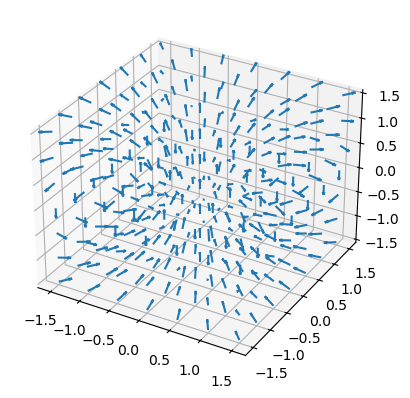

In [3]:
# Graph to see if it works fine
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

field = field/(np.sqrt(field[0]**2 + field[1]**2 + field[2]**2))
ax.quiver(xp, yp, zp, field[0], field[1], field[2], length=0.2, normalize=True)

In [ ]:
# Check if field calculation at point works

# Define parameters and initial values
a = 1
b = 0.5
test_r = np.array([0, -(a + 0.2), 0])
test_v = np.array([np.random.uniform(0.03, 0.12), -np.random.uniform(0.03, 0.12), -np.random.uniform(0.03, 0.12)])
test_pos = np.concatenate((test_r, test_v))

# Calculate field at point
# Toroidal field
test_field_tor = MagneticVector(sym_loop_tor, test_r)
# Plasma current field
test_field_plasma =  MagneticVector(sym_loop_plasma,  test_r)
# Total field
test_field = test_field_tor + test_field_plasma


c:\Users\JUAN\Downloads\projects\functions.py:120: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  X = sci.integrate.quad(dBxdv, a, b, args=(x, y, z))[0]
c:\Users\JUAN\Downloads\projects\functions.py:121: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
 

[ 0.11074398 -0.06471703 -0.10570825]


array([-0.17546102, -0.10822612, -0.04099122])

In [ ]:
# Create physics

# Charge mass ratio
qm = 1

# Lorentz force for the coil fields on the charge
def Lorentz(t, pos):
    # Constants
    qm = 1
    # Separate position array
    r = pos[0:3]
    v = pos[3:6]

    # Calculate fields
    field_tor = MagneticVector(sym_loop_tor, r)
    field_plasma = MagneticVector(sym_loop_plasma, r)
    field_1 = MagneticVector(sym_loop_1, r)
    field_2 = MagneticVector(sym_loop_2, r)
    field_3 = MagneticVector(sym_loop_3, r)
    field_4 = MagneticVector(sym_loop_4, r)
    field_pol = field_1 + field_2 + field_3 + field_4

    # weights for each field
    B = 0.5*field_tor + 1*field_plasma + 0.3*field_pol

    # Calculate acceleration
    a = qm*(np.cross(v, B))

    # Organize output
    out = np.concatenate((v, a))
    return out

# Test
a_test = Lorentz(0, test_pos)
a_test

array([ 0.11074398, -0.06471703, -0.10570825,  0.69119   , -0.58237564,
        1.08066077])

(-1.5, 1.5)

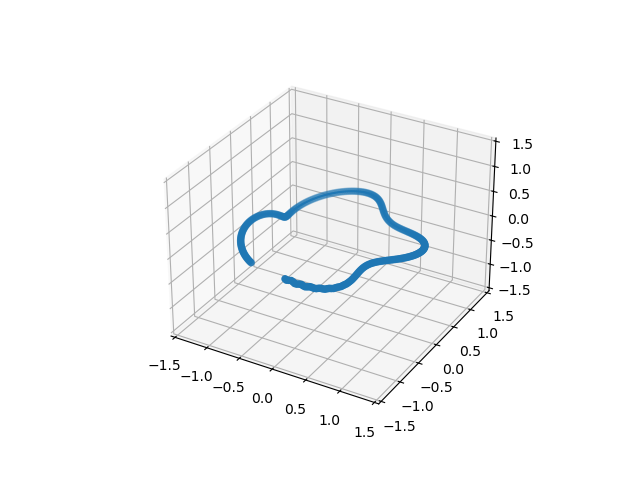

In [ ]:
# magic for interactive plot
%matplotlib widget

# Test time interval
t0 = 0
test_tf = 20
test_dt = 0.08

# Try with random velocity and position
# Top values for variation
r_top_lim = 0.07
v_top_lim = 0.2
# Particle parameters
test_r_1 = np.array([0, -(a + 0.2), 0]) + np.array([0, -np.random.uniform(0.01, r_top_lim), 0])
test_v_1 = np.array([0.3, -0.3, -0.3]) + np.random.uniform(0, v_top_lim, (3))
test_pos_1 = np.concatenate((test_r_1, test_v_1))


# Test solution
test_sol_1 = RK4(Lorentz, test_tf, test_dt, test_pos_1)

# Test plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(test_sol_1[:, 0], test_sol_1[:, 1], test_sol_1[:, 2])
ax.scatter(test_sol_1[:, 0], test_sol_1[:, 1], test_sol_1[:, 2])

# change to correst aspect ratio
ax.set_xlim(-b-a,b+a) 
ax.set_ylim(-b-a,b+a)
ax.set_zlim(-b-a,b+a) 

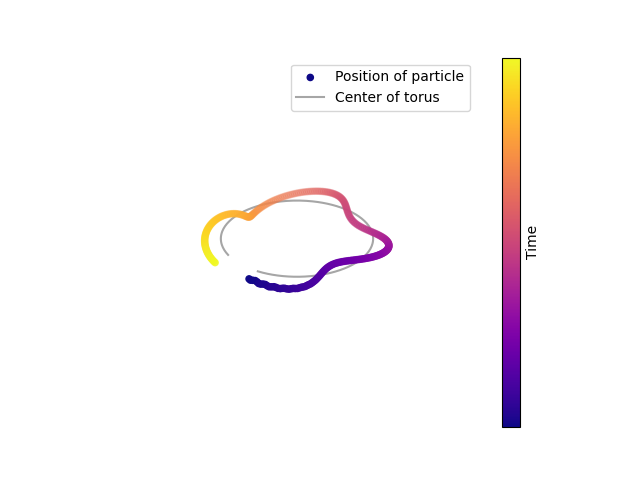

In [ ]:
# Plot
fig_2 = plt.figure()
ax_2 = fig_2.add_subplot(111, projection='3d')


# Make weights to make points change color as time passes
test_tn = int(test_tf/test_dt)
weights = np.linspace(0, 1, test_tn)

sc = ax_2.scatter(test_sol_1[:, 0], test_sol_1[:, 1], test_sol_1[:, 2], c=weights, cmap='plasma', label='Position of particle')


# to also plot main axis line
# Anlge corresponding to point
angle = abs(np.arctan2(test_sol_1[:, 0], test_sol_1[:, 1])- np.pi)
# Point in toroid center corresponding to angle
center = np.transpose(np.array([a*np.sin(angle), -a*np.cos(angle), np.zeros(len(angle))]))

# plot
ax_2.plot(center[:, 0], center[:, 1], center[:, 2], c='grey', alpha=0.7, label='Center of torus')

# put colorbar to show how time changes
cbar = plt.colorbar(sc)

# aspect ratio changes
ax_2.set_xlim(-b-a,b+a) 
ax_2.set_ylim(-b-a,b+a)
ax_2.set_zlim(-b-a,b+a) 

# put legend
plt.legend()

# No axis numbers on plot
ax_2.set_xticklabels([])
ax_2.set_yticklabels([])
ax_2.set_zticklabels([])
# No axes
ax_2.axis('off')

# No axis numbers on colorbar
cbar.set_ticks([])
# Colorbar title
cbar.set_label('Time')


Text(0, 0.5, 'Distance from particle to center of torus')

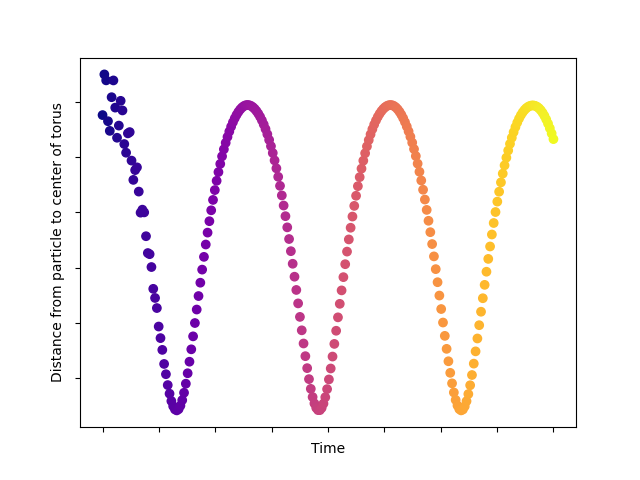

In [ ]:
# Check distance from particle to main axis

# Time linspace
test_t = np.linspace(t0, test_tf, test_tn)

# Distance from particle to toroid center
dist = np.sqrt((test_sol_1[:, 0] - center[:, 0])**2 + (test_sol_1[:, 1] - center[:, 1])**2 + (test_sol_1[:, 2] - center[:, 2])**2)

# Plot
fig1 = plt.figure()
ax1 = fig1.add_subplot(111)

ax1.scatter(test_t, dist, c=weights, cmap='plasma')

# no numbers on axis
ax1.set_xticklabels([])
ax1.set_yticklabels([])

# axis labels
ax1.set_xlabel('Time')
ax1.set_ylabel('Distance from particle to center of torus')

In [ ]:
# Now the center drifts
def Drifts(t, pos):
    # Separate position array
    r = pos[0:3]
    rnorm = np.sqrt(r[0]**2 + r[1]**2 + r[2]**2)
    v = pos[3:6]
    vnorm = np.sqrt(v[0]**2 + v[1]**2 + v[2]**2)

    # Calculate fields
    field_tor = MagneticVector(sym_loop_tor, r)
    field_plasma = MagneticVector(sym_loop_plasma, r)
    # add poloidal fields for the drift corrections
    # field_1 = MagneticVector(sym_loop_1, r)
    # field_2 = MagneticVector(sym_loop_2, r)
    # field_3 = MagneticVector(sym_loop_3, r)
    # field_4 = MagneticVector(sym_loop_4, r)
    # field_pol = field_1 + field_2 + field_3 + field_4

    # weights for the fields
    # B = 0.15*field_tor + 1*field_plasma
    B = 0.15*field_tor
    # norm of the total field
    Bnorm = np.sqrt(B[0]**2 + B[1]**2 + B[2]**2)

    # Make velocity in the same direction as the field
    vel = 3*vnorm*(B/Bnorm) 

    # Calculate the drifts and resulting velocity
    # grad b drift
    gradprp = np.cross(B, np.gradient(B))/(Bnorm**2)
    # curve drift
    curv = np.cross(r, B)/(Bnorm**2)
    # resulting velocity
    vel += -0.35*gradprp + 0*curv
    # vel += 0
    # Calculate the force
    # parallel drift
    # Bprl = np.dot(B, r)*r/(rnorm**2)
    # accel = -0.1*np.gradient(Bprl)
    # no acceleration
    # accel = np.array([0,0,0])
    # acceleration hole of torus to see the grad b drift more clearly
    accel = -1.3*r

    # Organize output
    out = np.concatenate((vel, accel))
    return out
    
# Test function
# Drifts(0, test_pos)



# Join lorentz force and drifts
def join(t, pos):
    return Lorentz(t, pos) + Drifts(t, pos)

# Test
# join(0, test_pos)

(-1.5, 1.5)

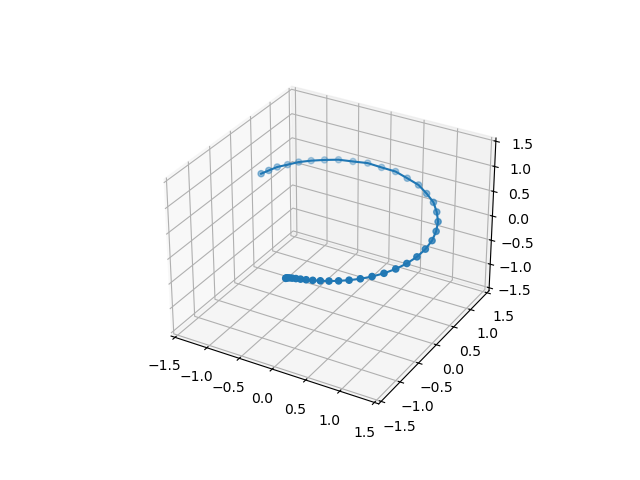

In [ ]:
# Simulation for the drifts

%matplotlib widget

# Test time interval
t0 = 0
test_tf = 2
test_dt = 0.05

# Try with random velocity and position
# Top values for variation
r_top_lim = 0.07
v_top_lim = 0.2

# test_r_1 = np.array([0, -(a + 0.2), 0]) + np.array([0, -np.random.uniform(0.01, r_top_lim), 0])
# try with set position
test_r_1 = np.array([0, -(a + 0.2), 0])
# test_v_1 = -1*np.array([0.3, -0.3, -0.3]) - np.random.uniform(0, v_top_lim, (3))
# try with no velocity
test_v_1 = np.array([0, -0, -0])
# orgainize particle parameters
test_pos_1 = np.concatenate((test_r_1, test_v_1))


# Test solution
drift_sol_1 = RK4(Drifts, test_tf, test_dt, test_pos_1)

# Test plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(drift_sol_1[:, 0], drift_sol_1[:, 1], drift_sol_1[:, 2])
ax.scatter(drift_sol_1[:, 0], drift_sol_1[:, 1], drift_sol_1[:, 2])

ax.set_xlim(-b-a,b+a) 
ax.set_ylim(-b-a,b+a)
ax.set_zlim(-b-a,b+a) 

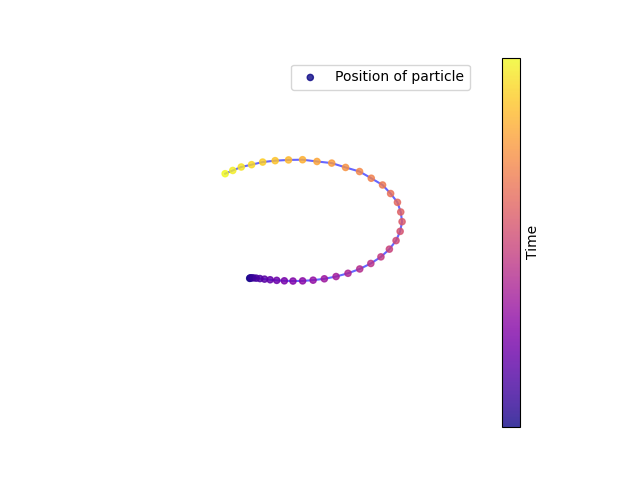

In [ ]:
# Good plot
fig_2 = plt.figure()
ax_2 = fig_2.add_subplot(111, projection='3d')


# Make weights to make points change color as time passes
test_tn = int(test_tf/test_dt)
weights = np.linspace(0, 1, test_tn)

sc = ax_2.scatter(drift_sol_1[:, 0], drift_sol_1[:, 1], drift_sol_1[:, 2], c=weights, cmap='plasma', label='Position of particle', alpha=0.8)
ax_2.plot(drift_sol_1[:, 0], drift_sol_1[:, 1], drift_sol_1[:, 2], c='blue', alpha=0.6)
# for plotting the poloidal coils when using their correction
# ax_2.plot(ploop_1[0], ploop_1[1], ploop_1[2], c='blue', alpha=0.4, label='Poloidal coils')
# ax_2.plot(ploop_2[0], ploop_2[1], ploop_2[2], c='blue', alpha=0.4)
# ax_2.plot(ploop_3[0], ploop_3[1], ploop_3[2], c='blue', alpha=0.4)
# ax_2.plot(ploop_4[0], ploop_4[1], ploop_4[2], c='blue', alpha=0.4)


cbar = plt.colorbar(sc)

ax_2.set_xlim(-b-a,b+a) 
ax_2.set_ylim(-b-a,b+a)
ax_2.set_zlim(-b-a,b+a) 

plt.legend()

# No axis numbers on plot
ax_2.set_xticklabels([])
ax_2.set_yticklabels([])
ax_2.set_zticklabels([])
# No axes
ax_2.axis('off')

# No axis numbers on colorbar
cbar.set_ticks([])
# Colorbar title
cbar.set_label('Time')
